<a href="https://colab.research.google.com/github/Sushanttyagi2/LIDS-for-Secure-Wireless-Sensor-Networks/blob/main/Notebook/WSN_IDS_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Dataset Created
   packet_rate  drop_rate    energy  label
0    18.001339   0.071241  0.660642      0
1    65.487547   0.042384  0.532910      0
2    49.588261   0.074284  0.800618      0
3    64.597222   0.097455  0.579462      0
4    31.983311   0.081414  0.807179      0

📊 Model Performance:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00        30

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140


🚨 Detection Result: ATTACK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


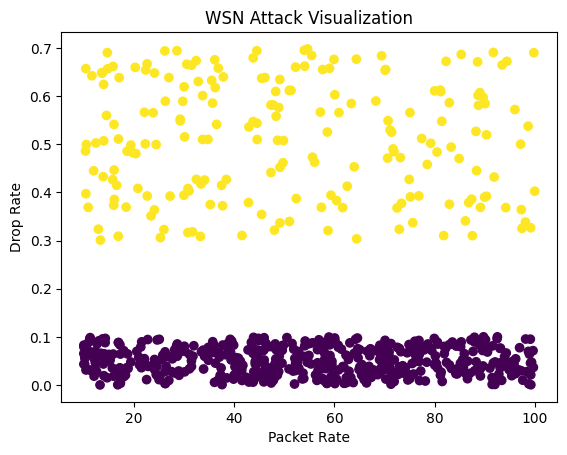

In [1]:
# ===============================
# Lightweight IDS for WSN on google colab
# ===============================

# Install libraries
!pip install numpy pandas scikit-learn matplotlib

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# ===============================
# 1. Data Simulation
# ===============================
def generate_data(num_nodes=100, attack=False):
    data = []

    for i in range(num_nodes):
        packet_rate = np.random.uniform(10, 100)
        drop_rate = np.random.uniform(0, 0.1)
        energy = np.random.uniform(0.5, 1.0)

        label = 0  # normal

        if attack:
            drop_rate = np.random.uniform(0.3, 0.7)
            energy = np.random.uniform(0.1, 0.4)
            label = 1  # attack

        data.append([packet_rate, drop_rate, energy, label])

    return pd.DataFrame(data, columns=["packet_rate", "drop_rate", "energy", "label"])


# Create dataset
normal = generate_data(500, attack=False)
attack = generate_data(200, attack=True)
df = pd.concat([normal, attack])

print("✅ Dataset Created")
print(df.head())

# ===============================
# 2. Train Model
# ===============================
X = df[["packet_rate", "drop_rate", "energy"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("\n📊 Model Performance:\n")
print(classification_report(y_test, predictions))

# ===============================
# 3. Rule-Based Detection
# ===============================
def rule_based_detection(packet_rate, drop_rate, energy):
    if drop_rate > 0.3 or energy < 0.3:
        return 1
    return 0

# ===============================
# 4. Hybrid Detection
# ===============================
def hybrid_detection(model, sample):
    ml_pred = model.predict([sample])[0]
    rule_pred = rule_based_detection(*sample)

    if ml_pred == 1 or rule_pred == 1:
        return "ATTACK"
    return "NORMAL"

# ===============================
# 5. Test Sample
# ===============================
sample = [50, 0.5, 0.2]  # suspicious node

result = hybrid_detection(model, sample)

print("\n🚨 Detection Result:", result)

# ===============================
# 6. Visualization
# ===============================
plt.scatter(df["packet_rate"], df["drop_rate"], c=df["label"])
plt.xlabel("Packet Rate")
plt.ylabel("Drop Rate")
plt.title("WSN Attack Visualization")
plt.show()
